In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
import tables_io
import matplotlib.pyplot as plt 
%matplotlib inline 


In [2]:
dir_wide_catalog = '../job/data/hlwas_cosmos_260120_UM_2026_01_22.parquet'
#dir_output = '../job/tomobinning_project_output/true_nz/equipopulated/three_bins/out/'
dir_output = '../job/tomobinning_project_output/spec_emulate_nz/equipopulated/three_bins/out/'


In [3]:
widegalaxy = tables_io.read(dir_wide_catalog)
widegalaxy_assignment = tables_io.read(dir_output + 'widedata_wide_assignment.hdf5')
tomotbinwide = tables_io.read(dir_output + 'tomo_bins_wide.hdf5')
widebinning = tomotbinwide['tomo_bins_wide'][:,0][widegalaxy_assignment['cells']]
tomotbinwide_ref = h5py.File(dir_output +'FINAL_NZ.hdf5','r')

column_list None


In [4]:
redshiftcol='specz'
zbinsc = tomotbinwide_ref['meta/xvals'][:][0]

In [5]:
tomotbinwide

OrderedDict([('tomo_bins_wide',
              array([[ 2.,  1.],
                     [-1., -1.],
                     [ 2.,  1.],
                     ...,
                     [ 0.,  1.],
                     [ 0.,  1.],
                     [ 0.,  1.]], shape=(1024, 2)))])

14657
14587
14653


(0.0, 3.2)

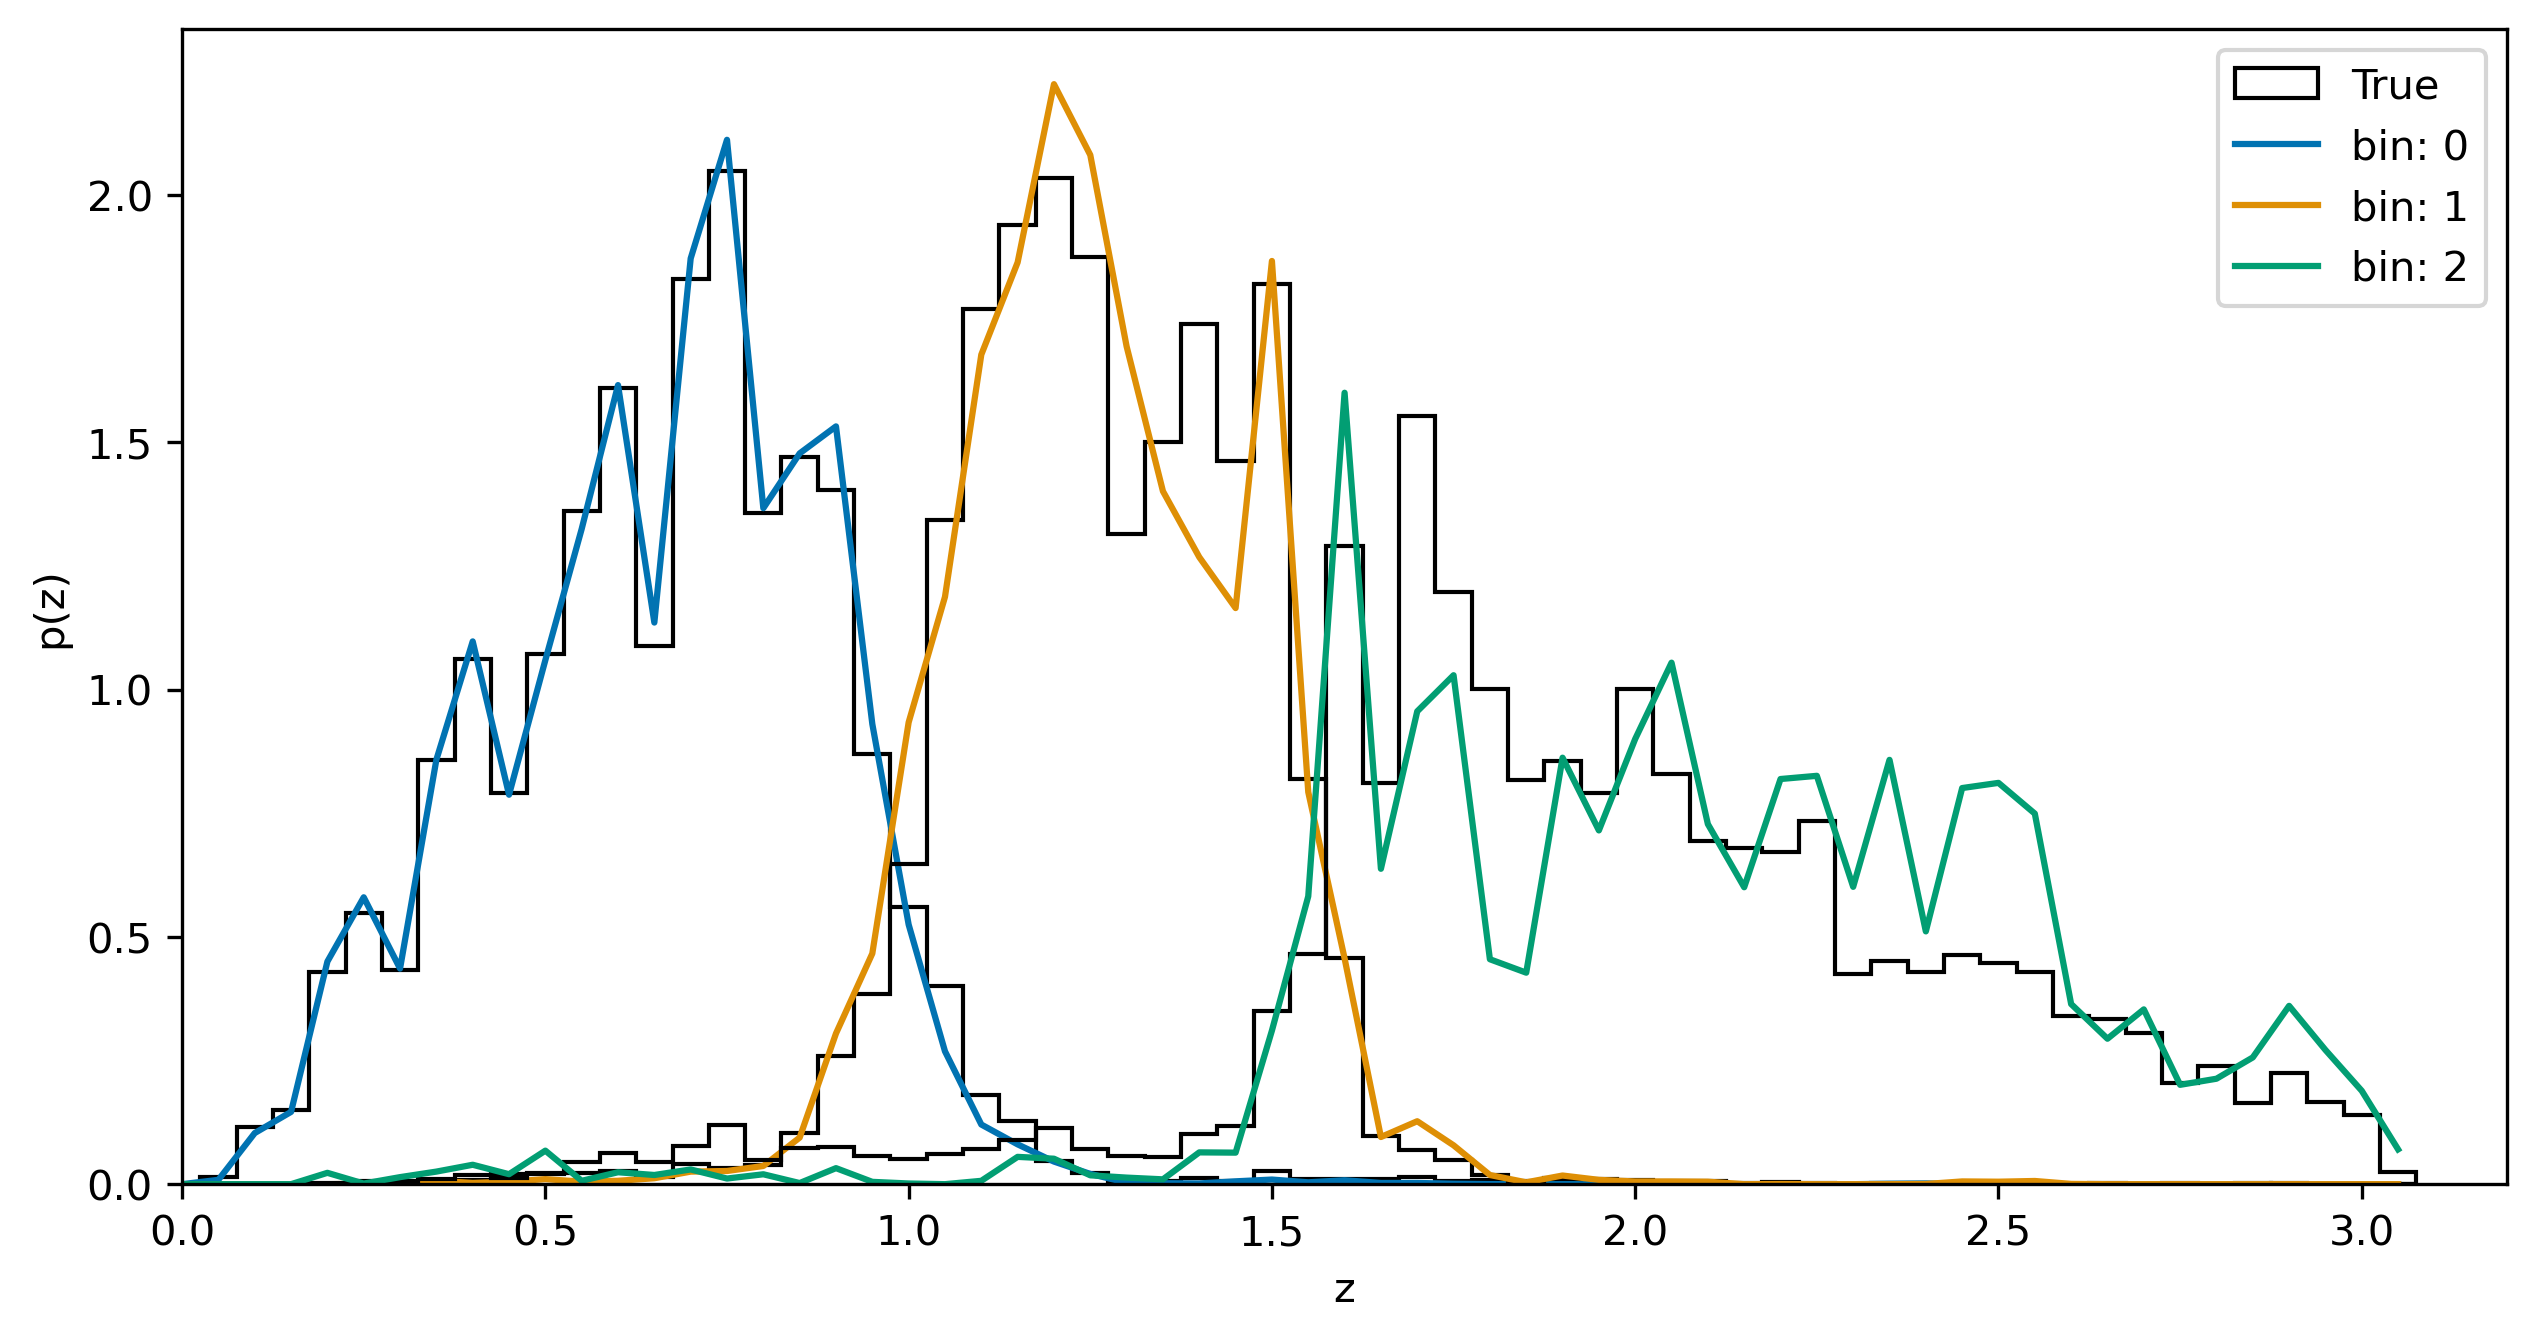

In [6]:
import seaborn as sns
colors = sns.color_palette('colorblind')
fig = plt.figure(figsize=(10,5), dpi = 300)
for i in range(int(np.max(widebinning))+1):
    if i==0:
        name="True"
    else:
        name=None
    bin_edges = np.append(zbinsc - 0.05/2, zbinsc[-1] + 0.05/2)
    plt.hist(np.array(widegalaxy[redshiftcol])[widebinning==i], density=True, histtype="step", bins=bin_edges, color='k', label=name)
    print(len(np.array(widegalaxy[redshiftcol])[widebinning==i]))
    plt.plot(zbinsc,tomotbinwide_ref['data/yvals'][:][i], "-", label="bin: "+str(i), c=colors[i])

plt.legend()
plt.xlabel("z")
plt.ylabel("p(z)")
plt.xlim(0,3.2)
